# C2 Tabular / ΔA Models — Results & Comparisons

Central plotting notebook for the tabular C2 classifiers (LR / RF / MLP) trained on
attribute vectors, C0 probability, embeddings and their counterfactual (ΔA) deltas.
Everything under sections 2–9 loads from `results/C2_custom_corrected/{disease}`
(currently: **effusion**). End-to-end CNN architectures live in **`ROC_cnn.ipynb`**.

| # | Section | Data source |
|---|---------|-------------|
| 1 | Setup — config, strategy registry, helpers | — |
| 2 | Data inventory — which runs exist | `cv_summary.csv` |
| 3 | ROC curves per model (single run) | `cv_detailed.json` |
| 4 | CF value ablation (B1 → B4 → M3) | `cv_detailed.json` |
| 5 | CF selection strategy comparison | `cv_summary.csv` |
| 6 | AUC vs CF count | `cv_summary.csv` |
| 7 | AUC heatmap — configs × strategy × CF count | `cv_summary.csv` |
| 8 | C0 confidence stratification | `cv_detailed.json` + fold predictions |
| 9 | Combining k CFs: avg-ΔA vs avg-scores vs stacking (k=3,16) | `cv_summary.csv` |
| 10 | Dual-CF isolation | `results/dual_cf_isolation` |
| 11 | Appendix: cross-architecture & dataset size | `results/C2_{custom,resnet50,vit}` |

Run **Setup** first; every other section is self-contained.
Section 5 reproduces `code/c2/c2_compare_selection_strategies.py`.

Each run directory looks like:
```
cv_results_<strategy>/cf_<k>/[distance_cosine/]
    cv_summary.csv            mean/std AUC per (model, config)
    cv_detailed.json          per-fold fpr/tpr/auc/y_prob/y_true (~90 MB)
    fold_<i>_predictions.csv  raw C0 prob + features per test sample
```

## 1. Setup — Imports, Config, Strategy Registry & Helpers

In [1]:
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '/zhome/d0/a/221493/thesis/code')
from plot_config import PLOT_COLORS, PLOT_LS, PLOT_LW

In [2]:
# ── Global config ─────────────────────────────────────────────────────────────
DISEASE     = 'effusion'                 # 'effusion' | 'pneumothorax' | 'cardiomegaly'
BASE_DIR    = '/zhome/d0/a/221493/thesis'
RESULTS_DIR = f'{BASE_DIR}/results/C2_custom_corrected/{DISEASE}'
OUTPUT_DIR  = 'images/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODELS      = ['LR', 'RF', 'MLP']
MODEL_NAMES = {'LR': 'Logistic Regression', 'RF': 'Random Forest',
               'MLP': 'Multilayer Perceptron'}

# Config groups
# B1: prob only   B2: attrs only   B3: emb only   B4: prob+attrs   B5: prob+emb
# M1: ΔA only     M2: prob+ΔA      M3: prob+ΔA+attrs   M4: prob+ΔA+emb
# M5: prob+ΔA+attrs+emb            M6: prob+ΔA+attrs+CF-prob
# MCF1: prob+CF-prob               MCF2: prob+CF-prob+attrs+CF-attrs
# MCF3: MCF2+ΔA   MCF4: MCF3+emb+CF-emb   MCF5: MCF4+Δemb
BASELINE_CONFIGS = ['B1', 'B2', 'B3', 'B4', 'B5']            # no CF information
DELTA_CONFIGS    = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']      # ΔA features
MCF_CONFIGS      = ['MCF1', 'MCF2', 'MCF3', 'MCF4', 'MCF5']  # raw CF features
CF_CONFIGS       = DELTA_CONFIGS + MCF_CONFIGS   # CF-dependent → differ across strategies
ALL_CONFIGS      = BASELINE_CONFIGS + CF_CONFIGS

LABELS = {
    'B1': 'B1 (Prob only)',        'B2': 'B2 (Attrs only)',
    'B3': 'B3 (Embeddings only)',  'B4': 'B4 (Prob+Attrs)',
    'B5': 'B5 (Prob+Emb)',         'M1': 'M1 (ΔA only)',
    'M2': 'M2 (Prob+ΔA)',          'M3': 'M3 (Prob+ΔA+Attrs)',
    'M4': 'M4 (Prob+ΔA+Emb)',      'M5': 'M5 (Prob+ΔA+Attrs+Emb)',
    'M6': 'M6 (Prob+ΔA+Attrs+CF)',
    'MCF1': 'MCF1 (Prob+CF-Prob)',
    'MCF2': 'MCF2 (Prob+CF-Prob+Attrs+CF-Attrs)',
    'MCF3': 'MCF3 (MCF2+ΔA)',
    'MCF4': 'MCF4 (MCF3+Emb+CF-Emb)',
    'MCF5': 'MCF5 (MCF4+ΔEmb)',
}

COLORS, LINESTYLES, LINEWIDTHS = PLOT_COLORS, PLOT_LS, PLOT_LW

In [3]:
# ── CF selection strategy / run-variant registry ──────────────────────────────
# key → (subdir under RESULTS_DIR, distance metric, plot label)
# Non-L1 runs live in a distance_<metric>/ subdir inside the cf_<k> directory.
# A '{cf}' placeholder means the run is nested inside another run's cf dir
# (feature-set variants: entropy replaces C0 prob / prob removed entirely).
STRATEGIES = {
    'correct_cf':          ('cv_results_correct_cf',          'l1',     'Correct CF (L1)'),
    'correct_cf_cosine':   ('cv_results_correct_cf',          'cosine', 'Correct CF (Cosine)'),
    'entropy':             ('cv_results_correct_cf/cf_{cf}/TEST_entropy',     'l1',
                            'Correct CF (Entropy for Prob)'),
    'no_prob':             ('cv_results_correct_cf/cf_{cf}/TEST_removedprob', 'l1',
                            'Correct CF (No Prob)'),
    
    # BIG MLP COMBINES ENSEMBLE AND ENTROPY
    'cf_ensemble_entropy': ('cv_results_cf_ensemble/cf_{cf}/TEST_entropy', 'l1',
                        'CF Ensemble + Entropy (avg k scores)'),

    # Ensemble retrained/evaluated on the class-balanced dataset (r1 strict)
    'cf_ensemble_balanced': ('cv_results_cf_ensemble/cf_{cf}/balanced_r1_strict', 'l1',
                        'CF Ensemble (balanced dataset)'),

    'correct_cf_emb':      ('cv_results_correct_cf_emb',      'l1',     'Correct CF (Emb. Space)'),
    'extended_correct_cf': ('cv_results_extended_correct_cf', 'l1',     'Correct CF (Extra Texture)'),
    'unmatched':           ('cv_results_unmatched',           'l1',     'Opposite Pred (L1)'),
    'unmatched_cosine':    ('cv_results_unmatched',           'cosine', 'Unmatched (Cosine)'),
    'gt_routing':          ('cv_results_gt_routing',          'l1',     'GT Routing (L1)'),
    'gt_routing_cosine':   ('cv_results_gt_routing',          'cosine', 'GT Routing (Cosine, oracle)'),
    'cf_ensemble':         ('cv_results_cf_ensemble',         'l1',     'CF Ensemble (avg k scores)'),
    'cf_stack':            ('cv_results_cf_stack',            'l1',     'CF Stack (meta-LR on k logits)'),
    'train_only':          ('cv_results',                     'l1',     'Matched (L1, Train Only)'),
}

STRATEGY_COLORS = {
    'correct_cf':          '#0072B2',   # blue          ── correct_cf pair
    'correct_cf_cosine':   '#56B4E9',   # sky blue      ──┘ (lighter sibling)
    'entropy':             '#D55E00',   # vermillion
    'no_prob':             '#009E73',   # green
    'correct_cf_emb':      '#CC79A7',   # pink
    'extended_correct_cf': '#9467BD',   # purple
    'unmatched':           '#E69F00',   # orange
    'unmatched_cosine':    '#F0E442',   # yellow        ──┘ (lighter sibling of orange)
    'gt_routing':          '#000000',   # black (oracle)
    'gt_routing_cosine':   '#7F7F7F',   # grey  (oracle sibling)
    'cf_ensemble':         '#5C3317',   # dark chocolate
    'cf_stack':            '#D2A679',   # light tan
    'train_only':          '#66A61E',   # olive
    'cf_ensemble_entropy': '#E41A1C',   # red (BIG MLP, combines ensemble and entropy)
    'cf_ensemble_balanced': '#17BECF',  # teal (ensemble on balanced dataset)
}


STRATEGY_MARKERS = {
    'correct_cf': 'o', 'correct_cf_cosine': 'v', 'entropy': '<', 'no_prob': '>',
    'correct_cf_emb': '^', 'extended_correct_cf': 'D', 'unmatched': 's',
    'unmatched_cosine': 'P', 'gt_routing': '*', 'gt_routing_cosine': 'X',
    'cf_ensemble': 'h', 'cf_stack': 'p', 'train_only': 'd',
    'cf_ensemble_entropy': 'X',
    'cf_ensemble_balanced': 'H',
}

CF_COUNTS = [1, 3, 5, 16]   # CF counts a run may exist for

In [5]:
# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'grid.alpha': 0.3,
    'grid.linewidth': 0.6, 'lines.linewidth': 1.8,
})

In [4]:
# ── Loading helpers ───────────────────────────────────────────────────────────
def run_dir(strategy, cf_count):
    """Directory of one (strategy, cf_count) run."""
    subdir, distance, _ = STRATEGIES[strategy]
    if '{cf}' in subdir:   # nested variant (e.g. TEST_entropy inside correct_cf)
        d = os.path.join(RESULTS_DIR, subdir.format(cf=cf_count))
    else:
        d = os.path.join(RESULTS_DIR, subdir, f'cf_{cf_count}')
    return d if distance == 'l1' else os.path.join(d, f'distance_{distance}')

def has_run(strategy, cf_count):
    return os.path.exists(os.path.join(run_dir(strategy, cf_count), 'cv_summary.csv'))

def load_summary(strategy, cf_count):
    """cv_summary.csv → tidy df filtered to MODELS × ALL_CONFIGS (None if missing)."""
    path = os.path.join(run_dir(strategy, cf_count), 'cv_summary.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df = df[df['model'].isin(MODELS) & df['config'].isin(ALL_CONFIGS)].copy()
    df.insert(0, 'strategy', strategy)
    df.insert(1, 'cf_count', cf_count)
    return df

_detailed_cache = {}
def load_detailed(strategy, cf_count):
    """cv_detailed.json → {model: {config: [fold dicts]}}. ~90 MB each → cached."""
    key = (strategy, cf_count)
    if key not in _detailed_cache:
        with open(os.path.join(run_dir(strategy, cf_count), 'cv_detailed.json')) as f:
            _detailed_cache[key] = json.load(f)
    return _detailed_cache[key]

common_fpr = np.linspace(0, 1, 300)

def mean_roc(folds):
    """Fold-averaged ROC curve and AUC from a list of fold dicts."""
    tprs = [np.interp(common_fpr, f['fpr'], f['tpr']) for f in folds]
    aucs = [f['auc'] for f in folds]
    return {'fpr': common_fpr, 'tpr': np.mean(tprs, axis=0), 'std': np.std(tprs, axis=0),
            'auc': np.mean(aucs), 'auc_std': np.std(aucs)}

def add_b1_line(ax, b1_auc, label='B1 (Prob only)'):
    """Thin light-grey dashed B1 reference — shown in every config-comparison plot."""
    ax.axhline(b1_auc, color=COLORS['B1'], linestyle=LINESTYLES['B1'],
               lw=LINEWIDTHS['B1'], label=f'{label} = {b1_auc:.3f}', zorder=1)

## 2. Data Inventory

Which (strategy × CF count) runs exist for the current disease — ✓ means a
`cv_summary.csv` is present. Anything not in the registry is listed below the table.

Notes:
- *Entropy for Prob* and *No Prob* are feature-set variants nested inside
  `cv_results_correct_cf/cf_<k>/TEST_entropy` / `TEST_removedprob` (M/MCF configs only,
  no B baselines). The lowercase `test_entropy` dir at cf_1 is an older superseded run.
- *CF Ensemble* trains on the nearest CF and averages the k test-time scores
  (`c2_cv_pipeline_cf_ensemble.py`).

In [5]:
inventory = pd.DataFrame(
    {f'CF={cf}': {STRATEGIES[s][2]: '✓' if has_run(s, cf) else '—' for s in STRATEGIES}
     for cf in CF_COUNTS}
)
print(f'Available runs — {DISEASE}  ({RESULTS_DIR})')
display(inventory)

# Result subdirs not covered by the registry (incomplete or experimental runs)
known = {subdir for subdir, _, _ in STRATEGIES.values()}
extra = sorted(d for d in os.listdir(RESULTS_DIR)
               if d.startswith('cv_results') and d not in known)
if extra:
    print('Not in registry (incomplete/experimental):', ', '.join(extra))

Available runs — effusion  (/zhome/d0/a/221493/thesis/results/C2_custom_corrected/effusion)


,CF=1,CF=3,CF=5,CF=16
Correct CF (L1),✓,✓,✓,✓
Correct CF (Cosine),✓,—,—,—
Correct CF (Entropy for Prob),✓,—,—,—
Correct CF (No Prob),✓,—,—,—
CF Ensemble + Entropy (avg k scores),—,—,—,✓
Correct CF (Emb. Space),✓,—,—,✓
Correct CF (Extra Texture),✓,✓,✓,✓
Opposite Pred (L1),✓,✓,✓,✓
Unmatched (Cosine),✓,—,—,—
GT Routing (L1),✓,—,✓,✓


Not in registry (incomplete/experimental): cv_results_dispersion


## 3. ROC Curves — per Model (single run)

Fold-averaged ROC curves for one chosen (strategy, CF count) run:
one figure per model with baselines + ΔA configs (left) and CF-enriched MCF configs (right).

In [6]:
# ── Which run to plot ─────────────────────────────────────────────────────────
ROC_STRATEGY = 'correct_cf'      # any key of STRATEGIES
ROC_CF_COUNT = 16

detailed = load_detailed(ROC_STRATEGY, ROC_CF_COUNT)
run_tag  = f'{STRATEGIES[ROC_STRATEGY][2]} | CF={ROC_CF_COUNT}'
print(f'Loaded {run_tag}  →  models: {[m for m in detailed if m in MODELS]}')

Loaded Correct CF (L1) | CF=16  →  models: ['LR', 'RF', 'MLP']


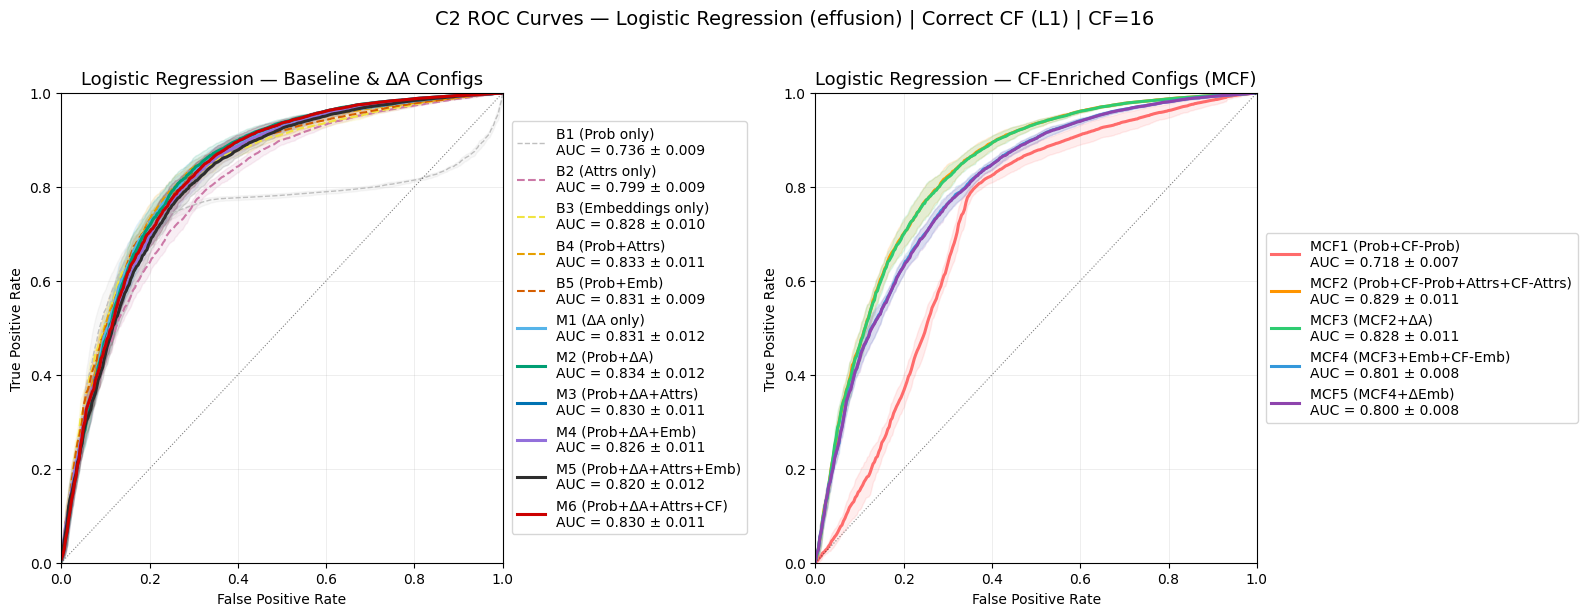

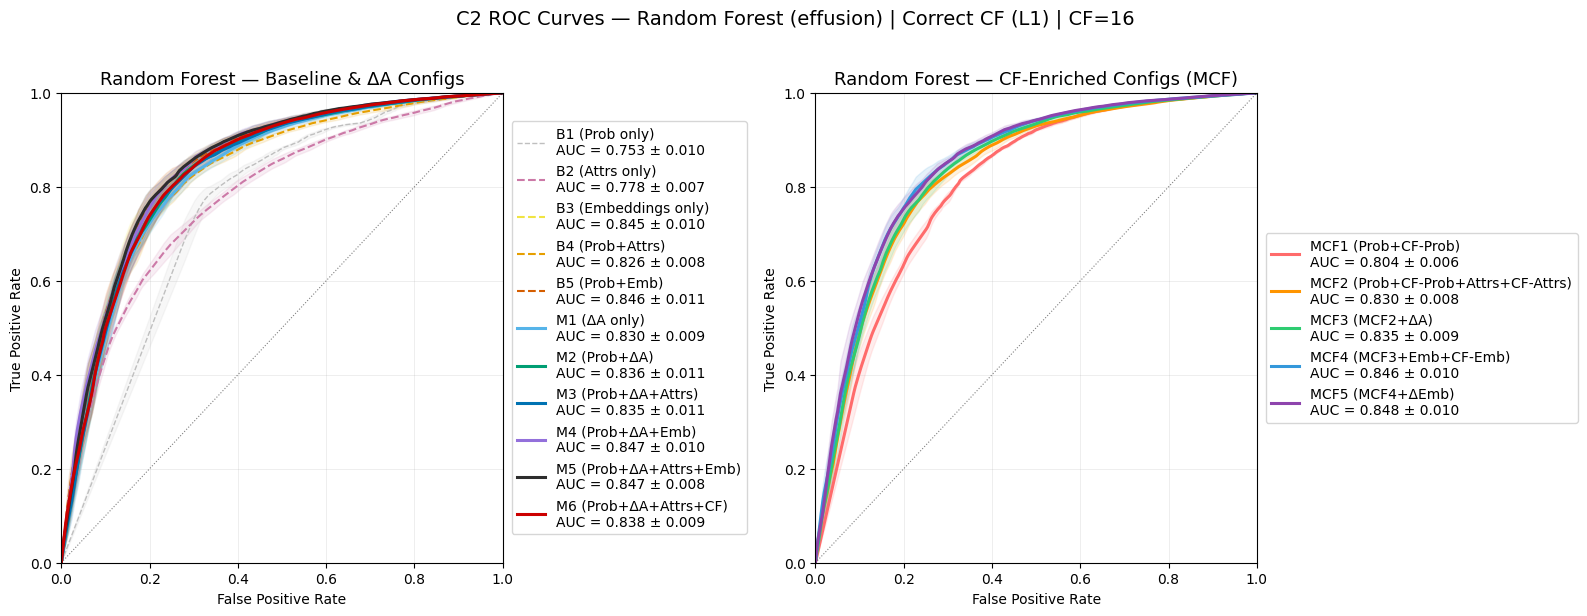

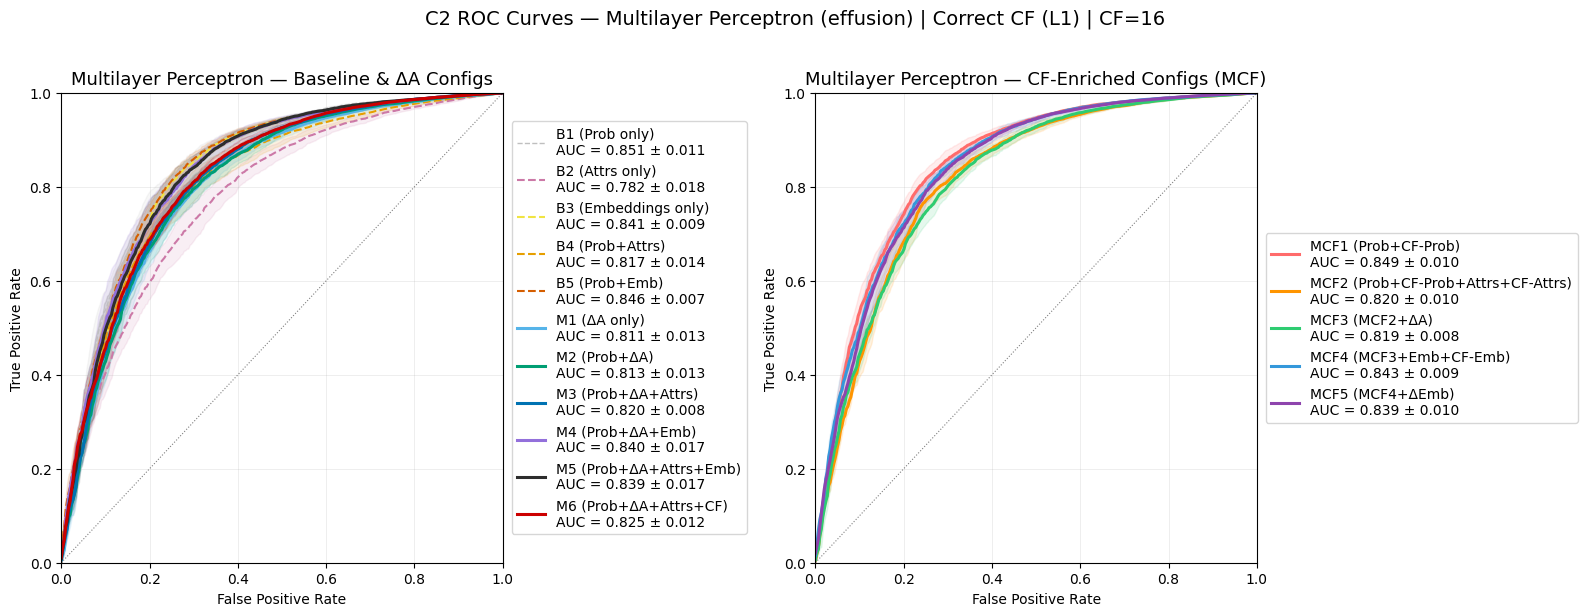

In [7]:
def plot_roc_panel(ax, model, configs, title):
    for config in configs:
        if config not in detailed[model]:
            continue
        d = mean_roc(detailed[model][config])
        ax.plot(d['fpr'], d['tpr'], color=COLORS[config],
                lw=LINEWIDTHS[config], ls=LINESTYLES[config],
                label=f"{LABELS[config]}\nAUC = {d['auc']:.3f} ± {d['auc_std']:.3f}")
        ax.fill_between(d['fpr'], d['tpr'] - d['std'], d['tpr'] + d['std'],
                        color=COLORS[config], alpha=0.12)
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title, size=13)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    ax.grid(alpha=0.30, linewidth=0.5)

for model in MODELS:
    fig, (ax_bm, ax_mcf) = plt.subplots(1, 2, figsize=(16, 6))
    plot_roc_panel(ax_bm, model, BASELINE_CONFIGS + DELTA_CONFIGS,
                   f'{MODEL_NAMES[model]} — Baseline & ΔA Configs')
    plot_roc_panel(ax_mcf, model, MCF_CONFIGS,
                   f'{MODEL_NAMES[model]} — CF-Enriched Configs (MCF)')
    fig.suptitle(f'C2 ROC Curves — {MODEL_NAMES[model]} ({DISEASE}) | {run_tag}',
                 size=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,
                f'roc_{model.lower()}_{ROC_STRATEGY}_cf{ROC_CF_COUNT}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
# ── AUC summary table for this run ────────────────────────────────────────────
summ = load_summary(ROC_STRATEGY, ROC_CF_COUNT)
tbl = summ.assign(auc=summ['mean_auc'].map('{:.3f}'.format) + ' ± '
                       + summ['std_auc'].map('{:.3f}'.format))
tbl = tbl.pivot(index='config', columns='model', values='auc').reindex(ALL_CONFIGS)[MODELS]
tbl.insert(0, 'Description', [LABELS[c] for c in tbl.index])
print(f'AUC (5-fold CV) — {DISEASE} | {run_tag}')
display(tbl)

AUC (5-fold CV) — effusion | Correct CF (L1) | CF=16


model,Description,LR,RF,MLP
config,,,,
B1,B1 (Prob only),0.736 ± 0.009,0.753 ± 0.010,0.851 ± 0.011
B2,B2 (Attrs only),0.799 ± 0.009,0.778 ± 0.007,0.782 ± 0.018
B3,B3 (Embeddings only),0.828 ± 0.010,0.845 ± 0.010,0.841 ± 0.009
B4,B4 (Prob+Attrs),0.833 ± 0.011,0.826 ± 0.008,0.817 ± 0.014
B5,B5 (Prob+Emb),0.831 ± 0.009,0.846 ± 0.011,0.846 ± 0.007
M1,M1 (ΔA only),0.831 ± 0.012,0.830 ± 0.009,0.811 ± 0.013
M2,M2 (Prob+ΔA),0.834 ± 0.012,0.836 ± 0.011,0.813 ± 0.013
M3,M3 (Prob+ΔA+Attrs),0.830 ± 0.011,0.835 ± 0.011,0.820 ± 0.008
M4,M4 (Prob+ΔA+Emb),0.826 ± 0.011,0.847 ± 0.010,0.840 ± 0.017


## 5. CF Selection Strategy Comparison

How the counterfactual neighbour is *chosen*, at a fixed CF count
(ported from `code/c2/c2_compare_selection_strategies.py`), plus the run variants:
entropy-for-prob, no-prob (both cf_1 only) and the CF score ensemble.
Only CF-dependent configs (M\*, MCF\*) differ across strategies; B\* baselines are
shown as reference lines — best baseline (black) and B1 (thin light-grey).

In [9]:
COMPARE_CF_COUNT = 1

# ── Which strategies to plot ──────────────────────────────────────────────────
# Edit this list to pick the strategies shown in Section 5.
# Set SELECTED_STRATEGIES = None to plot every strategy (except 'train_only').
# Keys: correct_cf, correct_cf_cosine, entropy, no_prob, correct_cf_emb,
#   extended_correct_cf, unmatched, unmatched_cosine, gt_routing,
#   gt_routing_cosine, cf_ensemble, cf_stack, train_only
SELECTED_STRATEGIES = [
    'correct_cf',
    'gt_routing',
    'unmatched',
    'correct_cf_emb']

COMPARE_STRATEGIES = ([s for s in STRATEGIES if s != 'train_only']
                      if SELECTED_STRATEGIES is None else SELECTED_STRATEGIES)


frames  = {s: load_summary(s, COMPARE_CF_COUNT) for s in COMPARE_STRATEGIES}
missing = [s for s, f in frames.items() if f is None]
if missing:
    print('⚠ No run found (skipped):', ', '.join(missing))
long_df = pd.concat([f for f in frames.values() if f is not None], ignore_index=True)

long_df.to_csv(os.path.join(OUTPUT_DIR,
               f'strategy_comparison_cf{COMPARE_CF_COUNT}_{DISEASE}.csv'), index=False)
print(f"{long_df['strategy'].nunique()} strategies loaded (CF={COMPARE_CF_COUNT}, {DISEASE})")

4 strategies loaded (CF=1, effusion)


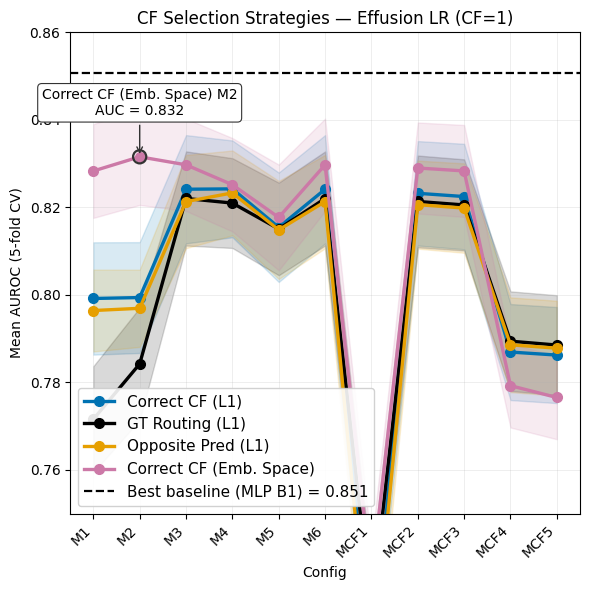

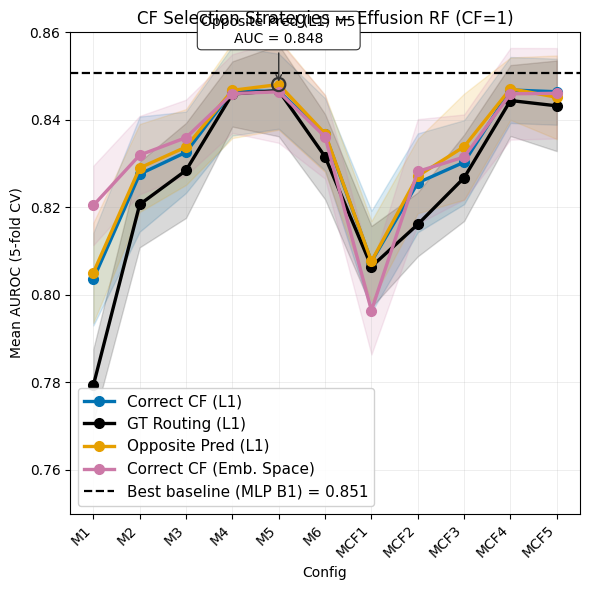

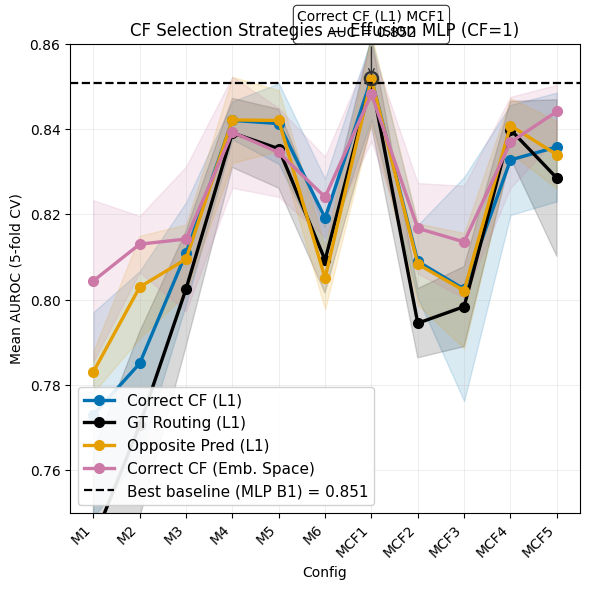

In [13]:
# ── Per-model comparison: x = CF-dependent config, one line per strategy ──────
def plot_strategy_comparison(long_df, model):
    sub = long_df[long_df['model'] == model]
    if sub.empty:
        print(f'⚠ No data for {model}')
        return
    
    
    # best baseline across ALL model families, not just this one
    base = long_df[long_df['config'].isin(BASELINE_CONFIGS)]
    best = base.loc[base['mean_auc'].idxmax()]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    for strategy in COMPARE_STRATEGIES:
        strat_df = sub[sub['strategy'] == strategy]
        present  = [c for c in CF_CONFIGS if c in strat_df['config'].values]
        if not present:
            continue
        strat_df = strat_df.set_index('config').loc[present]
        x    = [CF_CONFIGS.index(c) for c in present]
        y    = strat_df['mean_auc'].values
        yerr = strat_df['std_auc'].values
        ax.plot(x, y, color=STRATEGY_COLORS[strategy], lw=2.4, marker='o',
                markersize=7, label=STRATEGIES[strategy][2])
        ax.fill_between(x, y - yerr, y + yerr, color=STRATEGY_COLORS[strategy], alpha=0.15)

    # No-CF baselines (identical across strategies): best B* + the B1 reference
    if not base.empty:
        ax.axhline(best['mean_auc'], color='black', linestyle='--', lw=1.6,
                   label=f"Best baseline ({best['model']} {best['config']}) = {best['mean_auc']:.3f}")

    # annotate the single highest-AUC point across all plotted strategies
    plotted = sub[sub['strategy'].isin(COMPARE_STRATEGIES)
                  & sub['config'].isin(CF_CONFIGS)]
    if not plotted.empty:
        top = plotted.loc[plotted['mean_auc'].idxmax()]
        xt = CF_CONFIGS.index(top['config'])
        yt = top['mean_auc']
        ax.annotate(
            f"{STRATEGIES[top['strategy']][2]} {top['config']}\nAUC = {yt:.3f}",
            xy=(xt, yt), xytext=(0, 28), textcoords='offset points',
            ha='center', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#333333', lw=0.8),
            arrowprops=dict(arrowstyle='->', color='#333333', lw=1.0))
        ax.scatter([xt], [yt], s=90, facecolors='none',
                   edgecolors='#333333', linewidths=1.6, zorder=5)

    ax.set_xticks(range(len(CF_CONFIGS)))
    ax.set_xticklabels(CF_CONFIGS, rotation=45, ha='right')
    ax.set_ylim(0.75, 0.86)
    ax.set_xlabel('Config'); ax.set_ylabel('Mean AUROC (5-fold CV)')
    ax.set_title(f'CF Selection Strategies — {DISEASE.capitalize()} '
                 f'{model} (CF={COMPARE_CF_COUNT})')
    ax.legend(loc='lower left', framealpha=0.9, edgecolor='#cccccc', fontsize=11)
    ax.grid(alpha=0.3, linewidth=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,
                f'strategy_comparison_{model}_cf{COMPARE_CF_COUNT}_{DISEASE}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

for model in MODELS:
    plot_strategy_comparison(long_df, model)

In [14]:
# ── Leaderboards: strategy × config, one per model ────────────────────────────
for model in MODELS:
    sub = long_df[(long_df['model'] == model) & long_df['config'].isin(CF_CONFIGS)]
    if sub.empty:
        continue
    pivot = (sub.pivot(index='strategy', columns='config', values='mean_auc')
                .reindex(index=[s for s in COMPARE_STRATEGIES
                                if s in sub['strategy'].values],
                         columns=[c for c in CF_CONFIGS if c in sub['config'].values]))
    print(f'Leaderboard — {model} (mean AUC, 5-fold CV, CF={COMPARE_CF_COUNT})')
    display(pivot.round(4))

# Top 5 overall — CF-dependent configs only
top5 = (long_df[long_df['config'].isin(CF_CONFIGS)]
        .sort_values('mean_auc', ascending=False).head(5))
print('Top 5 overall (CF-dependent configs):')
display(top5[['strategy', 'model', 'config', 'mean_auc', 'std_auc']].round(4))

# print whole table for reference (uncomment if needed)
print('All results (CF-dependent configs):')
print(long_df[long_df['config'].isin(CF_CONFIGS)]
      .sort_values(['model', 'config', 'strategy']) )

# save full table
long_df.to_csv(os.path.join(OUTPUT_DIR,
               f'strategy_comparison_cf{COMPARE_CF_COUNT}_{DISEASE}.csv'), index=False)

Leaderboard — LR (mean AUC, 5-fold CV, CF=1)


config,M1,M2,M3,M4,M5,M6,MCF1,MCF2,MCF3,MCF4,MCF5
strategy,,,,,,,,,,,
correct_cf,0.7992,0.7994,0.8241,0.8242,0.8154,0.8241,0.7156,0.8232,0.8225,0.7869,0.7862
gt_routing,0.7715,0.7842,0.8220,0.8210,0.8151,0.8220,0.7273,0.8213,0.8205,0.7894,0.7885
unmatched,0.7964,0.7969,0.8213,0.8233,0.8148,0.8213,0.7111,0.8206,0.8198,0.7886,0.7878
correct_cf_emb,0.8283,0.8315,0.8297,0.8252,0.8177,0.8297,0.7345,0.8290,0.8283,0.7792,0.7765


Leaderboard — RF (mean AUC, 5-fold CV, CF=1)


config,M1,M2,M3,M4,M5,M6,MCF1,MCF2,MCF3,MCF4,MCF5
strategy,,,,,,,,,,,
correct_cf,0.8036,0.8276,0.8326,0.8466,0.8465,0.8367,0.8076,0.8256,0.8303,0.8468,0.8464
gt_routing,0.7793,0.8206,0.8284,0.8459,0.8467,0.8316,0.8064,0.8161,0.8268,0.8444,0.8432
unmatched,0.8050,0.8290,0.8338,0.8467,0.8481,0.8369,0.8076,0.8272,0.8339,0.8471,0.8452
correct_cf_emb,0.8204,0.8319,0.8359,0.8460,0.8464,0.8361,0.7964,0.8282,0.8315,0.8459,0.8461


Leaderboard — MLP (mean AUC, 5-fold CV, CF=1)


config,M1,M2,M3,M4,M5,M6,MCF1,MCF2,MCF3,MCF4,MCF5
strategy,,,,,,,,,,,
correct_cf,0.7729,0.7850,0.8109,0.8421,0.8413,0.8192,0.8519,0.8090,0.8025,0.8328,0.8358
gt_routing,0.7433,0.7705,0.8025,0.8391,0.8354,0.8093,0.8512,0.7944,0.7984,0.8399,0.8285
unmatched,0.7830,0.8029,0.8095,0.8422,0.8421,0.8050,0.8518,0.8083,0.8021,0.8408,0.8340
correct_cf_emb,0.8044,0.8130,0.8142,0.8393,0.8345,0.8241,0.8482,0.8167,0.8135,0.8369,0.8442


Top 5 overall (CF-dependent configs):


,strategy,model,config,mean_auc,std_auc
43,correct_cf,MLP,MCF1,0.8519,0.0096
139,unmatched,MLP,MCF1,0.8518,0.0104
91,gt_routing,MLP,MCF1,0.8512,0.0104
187,correct_cf_emb,MLP,MCF1,0.8482,0.0110
121,unmatched,RF,M5,0.8481,0.0103


All results (CF-dependent configs):
           strategy  cf_count model config  mean_auc   std_auc   min_auc  \
5        correct_cf         1    LR     M1  0.799161  0.012844  0.781824   
149  correct_cf_emb         1    LR     M1  0.828300  0.010723  0.812427   
53       gt_routing         1    LR     M1  0.771547  0.012128  0.753106   
101       unmatched         1    LR     M1  0.796401  0.009360  0.781007   
6        correct_cf         1    LR     M2  0.799368  0.012670  0.782695   
..              ...       ...   ...    ...       ...       ...       ...   
126       unmatched         1    RF   MCF4  0.847124  0.007126  0.835149   
31       correct_cf         1    RF   MCF5  0.846419  0.007549  0.833488   
175  correct_cf_emb         1    RF   MCF5  0.846062  0.010334  0.833282   
79       gt_routing         1    RF   MCF5  0.843195  0.010358  0.825730   
127       unmatched         1    RF   MCF5  0.845152  0.009564  0.829563   

      max_auc                           fold_aucs  

## 6. AUC vs CF Count

Effect of the number of counterfactuals for a fixed (model, config),
one line per strategy across all its available CF counts.
B1 uses no CFs → flat light-grey reference line.

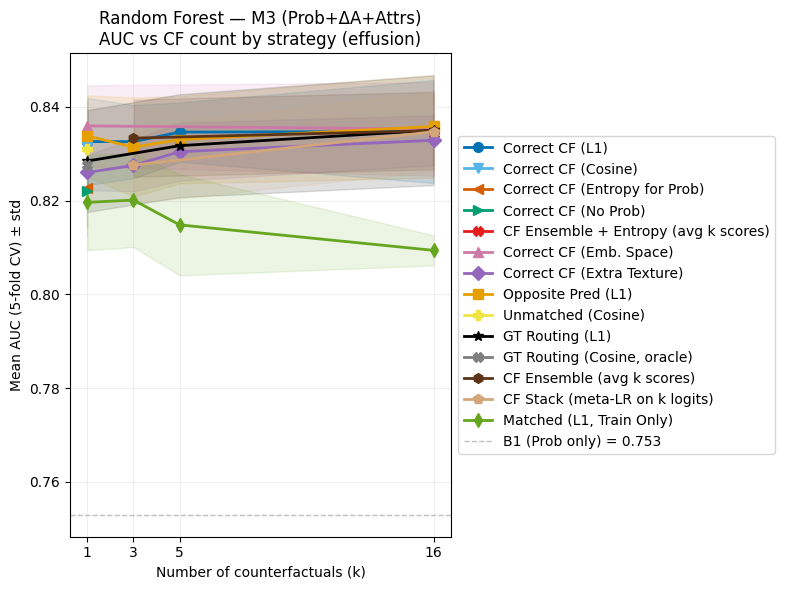

,CF=1,CF=3,CF=5,CF=16
Correct CF (L1),0.8326,0.8326,0.8346,0.8347
Correct CF (Cosine),0.8313,NaN,NaN,NaN
Correct CF (Entropy for Prob),0.8226,NaN,NaN,NaN
Correct CF (No Prob),0.8221,NaN,NaN,NaN
CF Ensemble + Entropy (avg k scores),NaN,NaN,NaN,0.8343
Correct CF (Emb. Space),0.8359,NaN,NaN,0.8353
Correct CF (Extra Texture),0.8260,0.8275,0.8304,0.8329
Opposite Pred (L1),0.8338,0.8314,0.8330,0.8358
Unmatched (Cosine),0.8311,NaN,NaN,NaN
GT Routing (L1),0.8284,NaN,0.8317,0.8350


In [15]:
FOCUS_MODEL  = 'RF'
FOCUS_CONFIG = 'M3'

fig, ax = plt.subplots(figsize=(8, 6))
b1_auc, table_rows = None, {}
for strategy in STRATEGIES:
    pts = []
    for cf in CF_COUNTS:
        df = load_summary(strategy, cf)
        if df is None:
            continue
        row = df[(df['model'] == FOCUS_MODEL) & (df['config'] == FOCUS_CONFIG)]
        if row.empty:
            continue
        pts.append((cf, row['mean_auc'].iloc[0], row['std_auc'].iloc[0]))
        if b1_auc is None:
            b1 = df[(df['model'] == FOCUS_MODEL) & (df['config'] == 'B1')]
            if not b1.empty:
                b1_auc = b1['mean_auc'].iloc[0]
    if not pts:
        continue
    cfs, means, stds = map(np.array, zip(*pts))
    ax.plot(cfs, means, color=STRATEGY_COLORS[strategy],
            marker=STRATEGY_MARKERS[strategy], lw=2, ms=7,
            label=STRATEGIES[strategy][2])
    ax.fill_between(cfs, means - stds, means + stds,
                    color=STRATEGY_COLORS[strategy], alpha=0.12)
    table_rows[STRATEGIES[strategy][2]] = {f'CF={c}': m for c, m, _ in pts}

if b1_auc is not None:
    add_b1_line(ax, b1_auc)

ax.set_xticks(CF_COUNTS); ax.set_xticklabels([str(c) for c in CF_COUNTS])
ax.set_xlabel('Number of counterfactuals (k)')
ax.set_ylabel('Mean AUC (5-fold CV) ± std')
ax.set_title(f'{MODEL_NAMES[FOCUS_MODEL]} — {LABELS[FOCUS_CONFIG]}\n'
             f'AUC vs CF count by strategy ({DISEASE})')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
ax.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,
            f'auc_vs_cf_count_{FOCUS_MODEL}_{FOCUS_CONFIG}_{DISEASE}.png'),
            dpi=300, bbox_inches='tight')
plt.show()

display(pd.DataFrame(table_rows).T.round(4))

## 7. AUC Heatmap — Configs × (Strategy × CF count)

Full overview per model, built from the `cv_summary.csv` files.
Black boxes mark the best config within each column; white lines separate
the B / M / MCF config groups (rows) and the strategy blocks (columns).

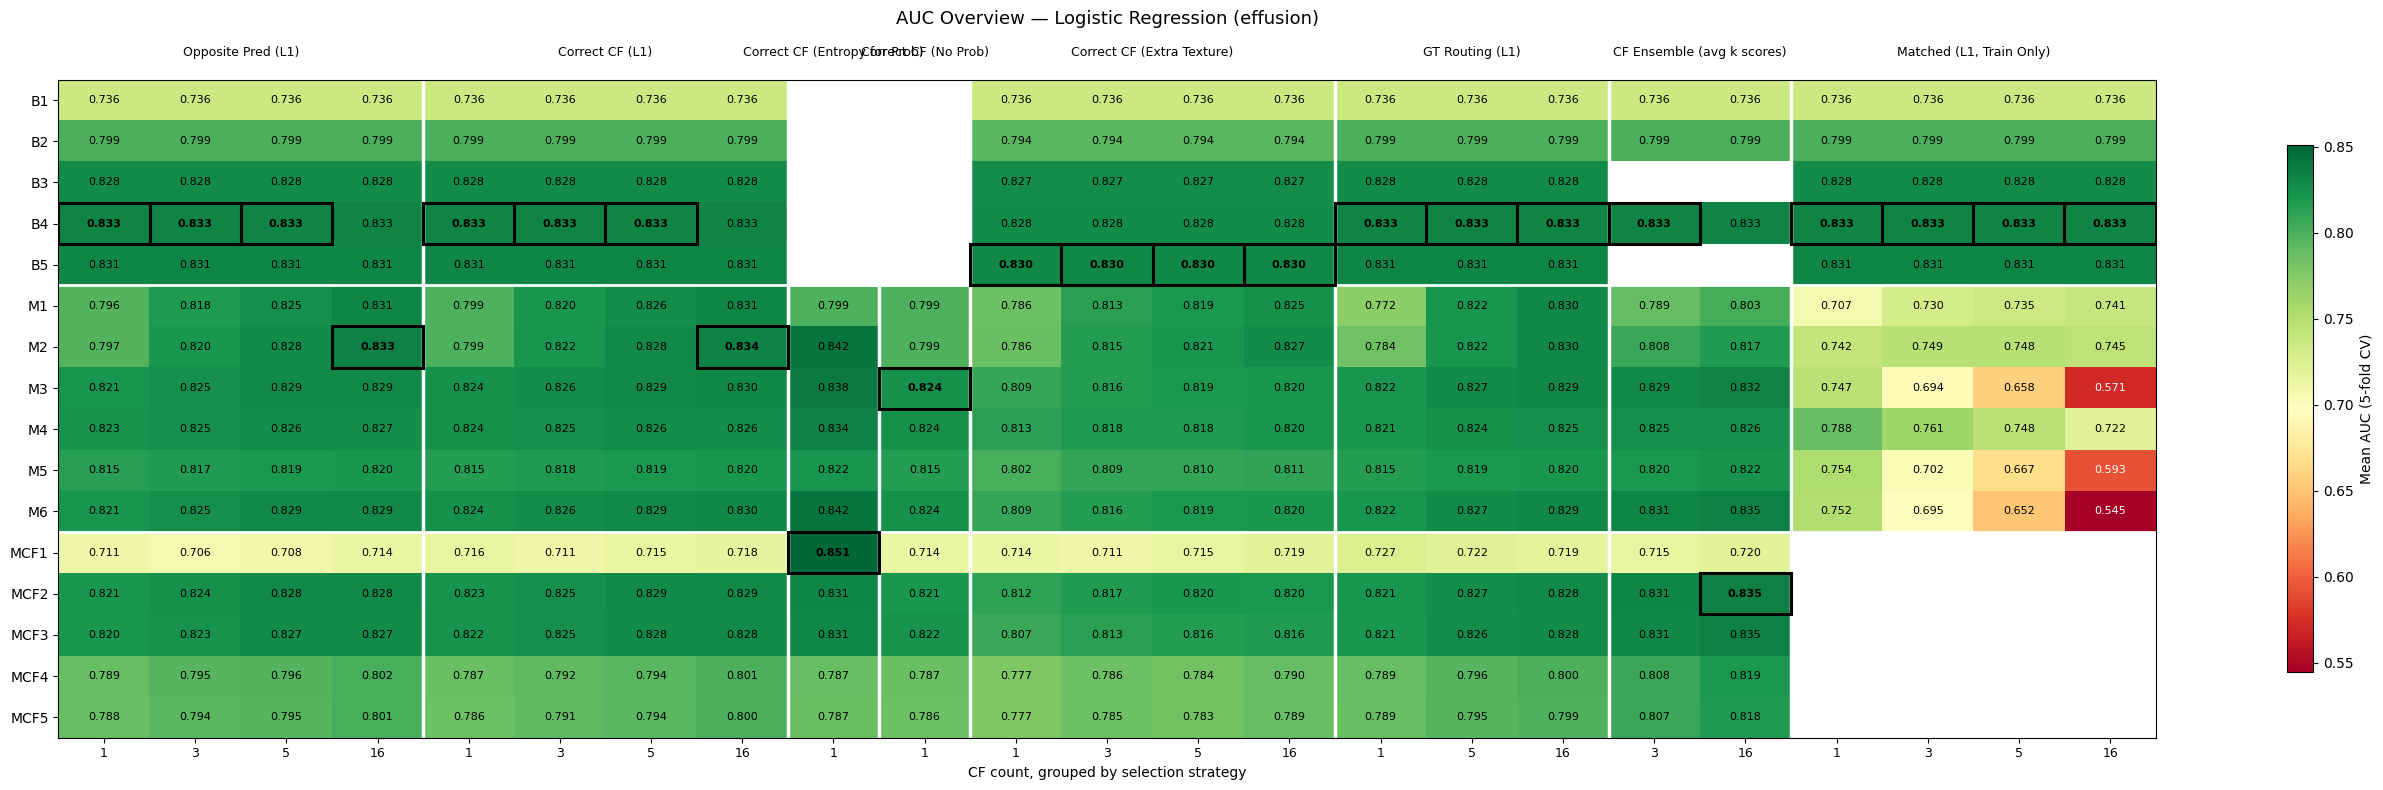

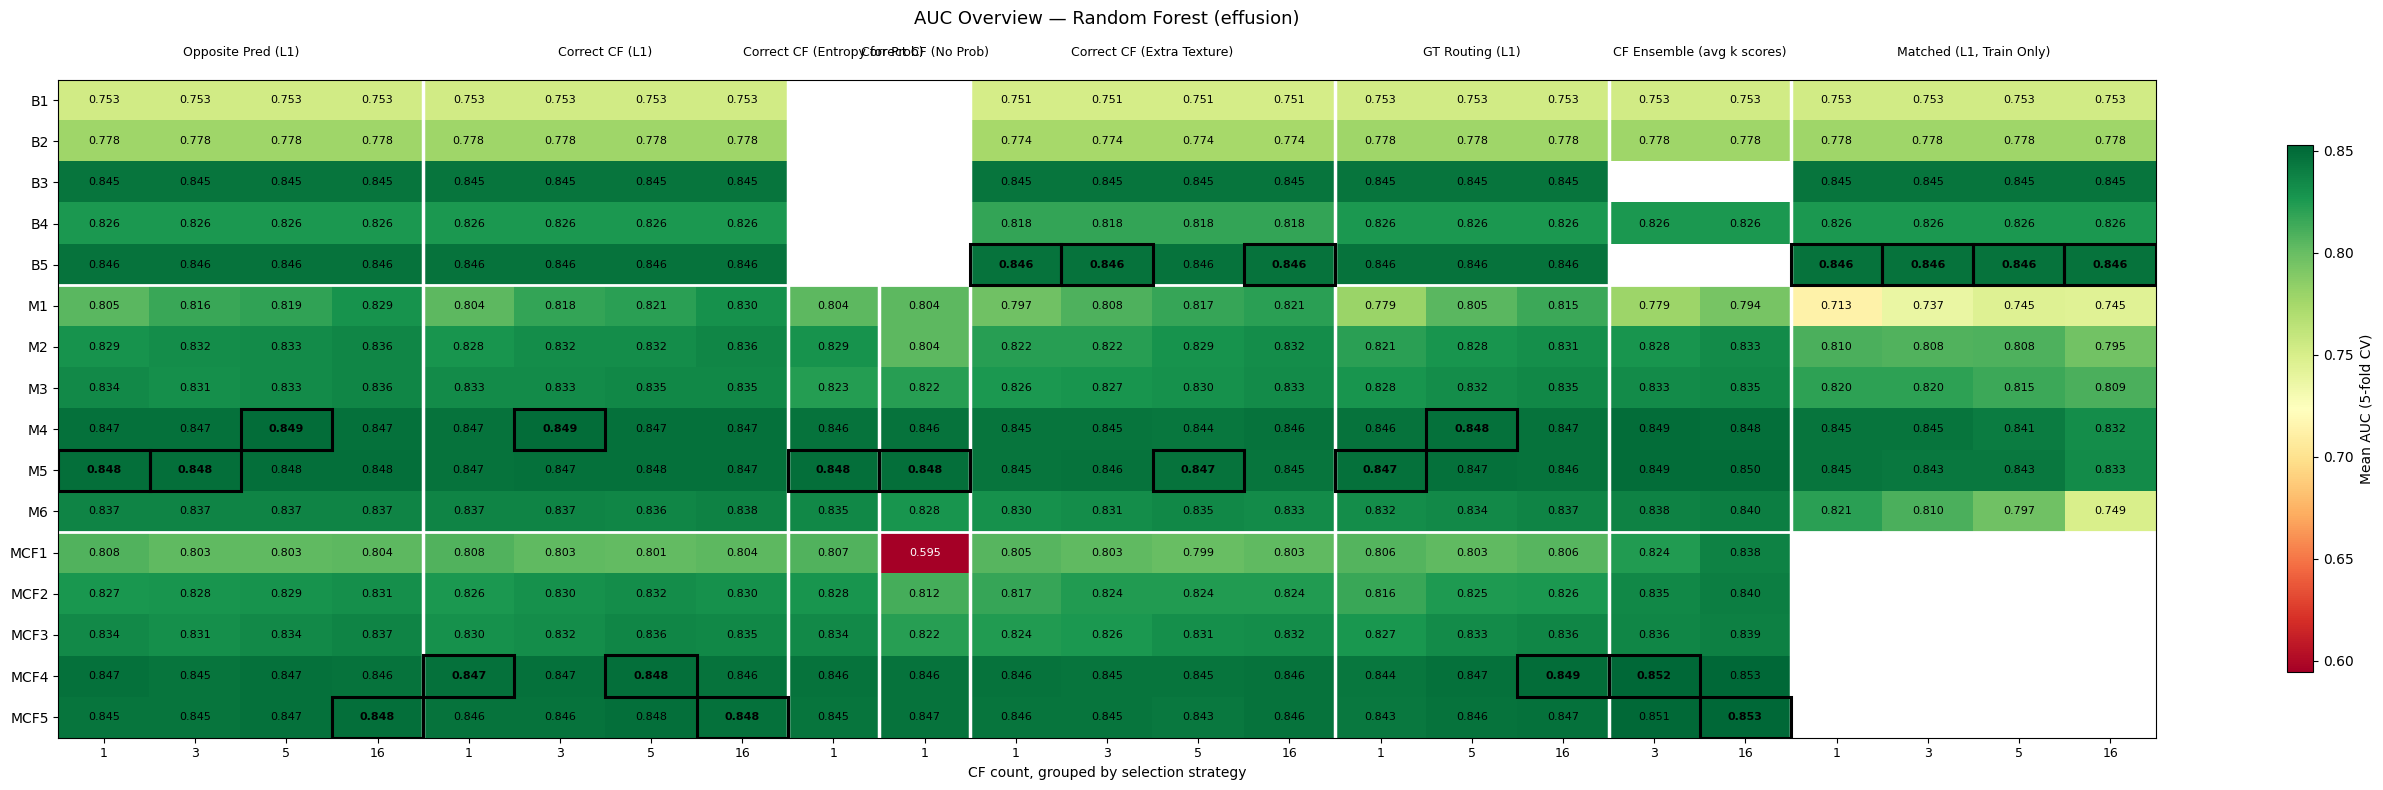

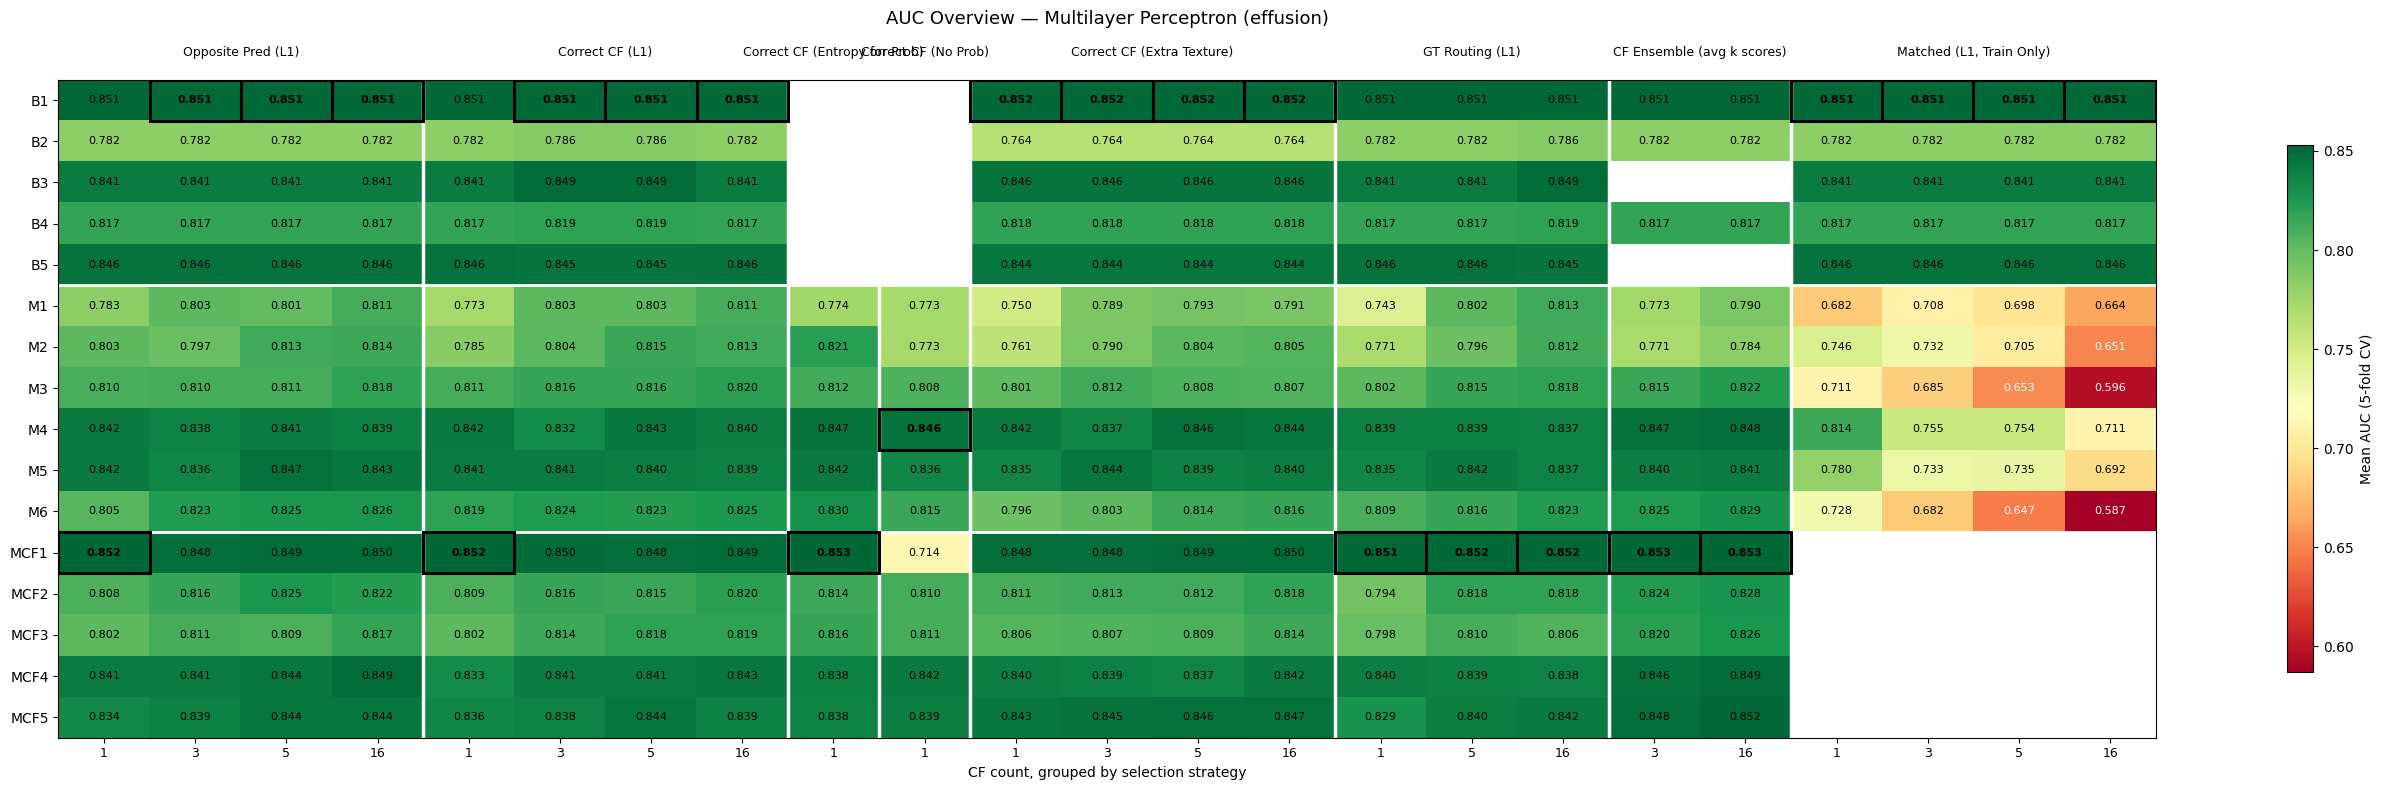

In [16]:
HEATMAP_STRATEGIES = ['unmatched', 'correct_cf', 'entropy', 'no_prob',
                      'extended_correct_cf', 'gt_routing', 'cf_ensemble',
                      'train_only']   # edit to subset

for model in MODELS:
    cols, col_labels, blocks = [], [], []
    for strategy in HEATMAP_STRATEGIES:
        n_before = len(cols)
        for cf in CF_COUNTS:
            df = load_summary(strategy, cf)
            if df is None:
                continue
            vals = (df[df['model'] == model].set_index('config')['mean_auc']
                    .reindex(ALL_CONFIGS).values)
            cols.append(vals)
            col_labels.append(str(cf))
        if len(cols) > n_before:
            blocks.append((n_before, len(cols), STRATEGIES[strategy][2]))
    if not cols:
        print('No data found for the heatmap strategies.')
        break
    mat = np.column_stack(cols)

    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    best_rows  = np.nanargmax(mat, axis=0)

    fig, ax = plt.subplots(figsize=(1.0 * mat.shape[1] + 4, 8))
    im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    for ri in range(mat.shape[0]):
        for ci in range(mat.shape[1]):
            val = mat[ri, ci]
            if np.isnan(val):
                continue
            brightness = (val - vmin) / max(vmax - vmin, 1e-6)
            is_best = ri == best_rows[ci]
            ax.text(ci, ri, f'{val:.3f}', ha='center', va='center', fontsize=8,
                    color='white' if brightness < 0.25 else 'black',
                    fontweight='bold' if is_best else 'normal')
            if is_best:
                ax.add_patch(plt.Rectangle((ci - .5, ri - .5), 1, 1, fill=False,
                                           edgecolor='black', lw=2.2, zorder=3))

    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(ALL_CONFIGS))); ax.set_yticklabels(ALL_CONFIGS, fontsize=10)
    ax.set_xlabel('CF count, grouped by selection strategy')

    # Row separators (B / M / MCF groups) and column separators (strategy blocks)
    ax.axhline(len(BASELINE_CONFIGS) - 0.5, color='white', lw=2)
    ax.axhline(len(BASELINE_CONFIGS) + len(DELTA_CONFIGS) - 0.5, color='white', lw=2)
    for start, end, lbl in blocks:
        if start > 0:
            ax.axvline(start - 0.5, color='white', lw=2.5)
        ax.text((start + end - 1) / 2, -1.0, lbl, ha='center', va='bottom',
                fontsize=9, clip_on=False)

    plt.colorbar(im, ax=ax, shrink=0.8, label='Mean AUC (5-fold CV)')
    ax.set_title(f'AUC Overview — {MODEL_NAMES[model]} ({DISEASE})', fontsize=13, pad=40)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'auc_heatmap_{model}_{DISEASE}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

## 9. Combining k CFs — Feature-Averaging vs Score-Averaging vs Learned Stacking

Three ways to turn k counterfactuals into one quality score, differing in *when* and *how* the k are combined:

- **Correct CF (avg ΔA)** — `cv_results_correct_cf`: the k nearest correct-CFs are collapsed into **one** feature row (ΔA averaged over the k), and a single classifier scores it (combine in *feature* space).
- **CF Ensemble (avg k scores)** — `cv_results_cf_ensemble`: the classifier is trained on the **nearest** CF only; at test time each of the k CFs is scored separately and the k probabilities are **averaged** (combine in *score* space, fixed mean).
- **CF Stack (meta-LR on k logits)** — `cv_results_cf_stack`: the **same** base model as the ensemble, but the k logits are combined by a **learned** meta-logistic-regression (the "final classification layer") fit on the 80% train fold, instead of a plain mean.

Because the stack shares the ensemble's base model, folds and seed, `stack_vs_avg` isolates the effect of *learning* the combiner. Compared at the CF counts where `correct_cf` also uses several CFs: **k = 3 and 16**. The **single-CF baseline** (`correct_cf` at k=1, before any multi-CF combination) is drawn as a dashed per-config reference so all three multi-CF curves read as gain-over-single-CF. B1 (prob only) is the light-grey flat reference; the B* AUCs are identical across runs by construction. The stack curve appears only once `cv_results_cf_stack` exists. **CF Ensemble (balanced dataset)** — `cv_results_cf_ensemble/cf_k/balanced_r1_strict`: the same score-averaging ensemble, but each **train** fold is subsampled to an exact 1:1:1:1 TP:FP:TN:FN quadrant pool (r1 strict; errors are also capped, so real errors are discarded). Test folds are untouched — identical images and natural prevalence as every other run — so AUCs are directly comparable and any gap is a *training* effect. Its B* baselines are trained on the same shrunken pool (B1 collapses: quadrant balancing destroys the prob→correctness link), so they are excluded from the best-baseline reference line.

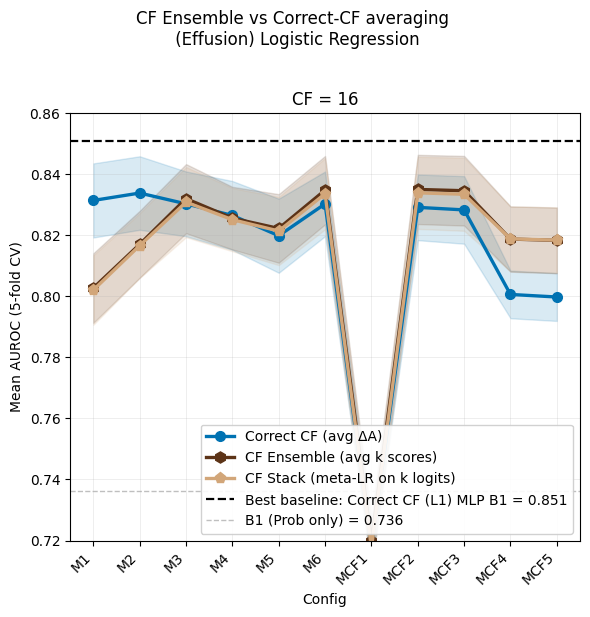

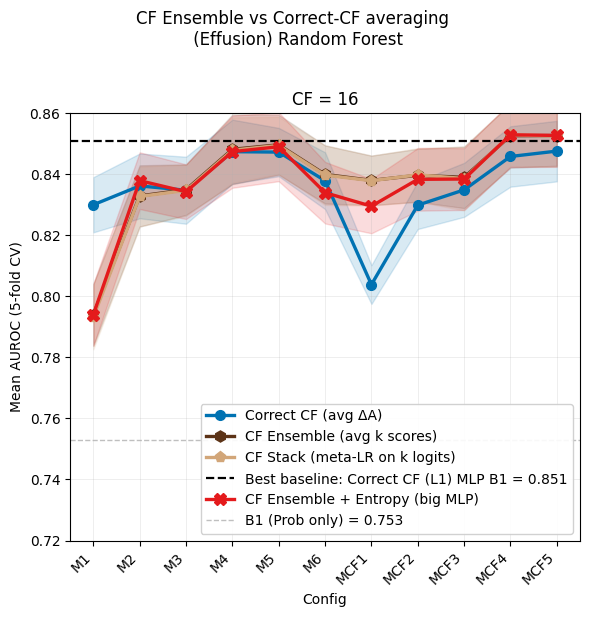

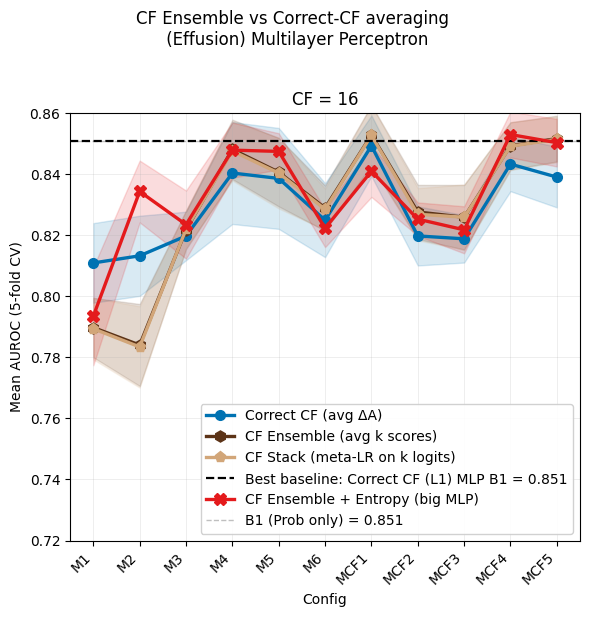

CF=16: ensemble beats correct_cf on 79% of (model,config) pairs; mean Δ = +0.0013


mean_auc_cor  mean_auc_ens  ens_vs_cor  ensemble_gain
model config                                                       
LR    M1            0.8314        0.8027     -0.0287         0.0359
      M2            0.8338        0.8170     -0.0168         0.0258
      M3            0.8303        0.8320      0.0017         0.0111
      M4            0.8265        0.8256     -0.0009         0.0051
      M5            0.8198        0.8222      0.0024         0.0084
      M6            0.8303        0.8348      0.0045         0.0122
      MCF1          0.7177        0.7198      0.0020         0.0041
      MCF2          0.8291        0.8350      0.0059         0.0129
      MCF3          0.8283        0.8346      0.0063         0.0133
      MCF4          0.8006        0.8187      0.0181         0.0344
      MCF5          0.7998        0.8183      0.0185         0.0347
MLP   M1            0.8109        0.7898     -0.0212         0.0460
      M2            0.8133        0.7840     -0.0292         0.0352
      M3            0.8198        0.8218      0.0020         0.0203
      M4            0.8404        0.8481      0.0077         0.0078
      M5            0.8386        0.8407      0.0020         0.0060
      M6            0.8249        0.8289      0.0040         0.0187
      MCF1          0.8493        0.8528      0.0035         0.0009
      MCF2          0.8198        0.8276      0.0078         0.0138
      MCF3          0.8188        0.8259      0.0071         0.0221
      MCF4          0.8433        0.8493      0.0060         0.0117
      MCF5          0.8391        0.8517      0.0126         0.0133
RF    M1            0.8300        0.7939     -0.0360         0.0509
      M2            0.8362        0.8329     -0.0033         0.0253
      M3            0.8347        0.8349      0.0002         0.0154
      M4            0.8474        0.8481      0.0008         0.0043
      M5            0.8472        0.8496      0.0024         0.0036
      M6            0.8379        0.8399      0.0021         0.0121
      MCF1          0.8038        0.8380      0.0341         0.0355
      MCF2          0.8299        0.8396      0.0098         0.0127
      MCF3          0.8349        0.8390      0.0041         0.0157
      MCF4          0.8458        0.8526      0.0068         0.0086
      MCF5          0.8476        0.8527      0.0051         0.0096

In [17]:
# ── CF Ensemble vs Correct-CF averaging, at cf=3 and cf=16 ────────────────────
# Two ways to use k counterfactuals:
#   correct_cf  — the k nearest correct-CFs are collapsed into ONE feature row
#                 (ΔA averaged over the k CFs); a single classifier scores it.
#   cf_ensemble — train on the nearest CF only, then at test time score each of
#                 the k CFs separately and AVERAGE the k output probabilities.
#   cf_stack    — same base model as cf_ensemble, but the k logits are combined
#                 by a learned meta-LR instead of a plain average.
# The ensemble/stack runs also store `mean_single_cf_auc` and their *_gain
# columns, isolating the test-time combiner effect.
ENS_CF_COUNTS = [16]        # correct_cf also uses multiple CFs at these counts

def _ens_frame(cf):
    # load_summary keeps every cv_summary column, incl. mean_single_cf_auc / ensemble_gain
    ens = load_summary('cf_ensemble', cf)
    cor = load_summary('correct_cf',  cf)
    if ens is None or cor is None:
        return None
    ens = ens[['cf_count', 'model', 'config', 'mean_auc', 'std_auc',
               'mean_single_cf_auc', 'ensemble_gain']]
    m = ens.merge(cor[['model', 'config', 'mean_auc', 'std_auc']],
                  on=['model', 'config'], suffixes=('_ens', '_cor'))
    m['ens_vs_cor'] = m['mean_auc_ens'] - m['mean_auc_cor']
    # Optional: learned-stack combiner on the same base logits (may be absent)
    stk = load_summary('cf_stack', cf)
    if stk is not None:
        stk = stk[['model', 'config', 'mean_auc', 'std_auc']].rename(
            columns={'mean_auc': 'mean_auc_stk', 'std_auc': 'std_auc_stk'})
        m = m.merge(stk, on=['model', 'config'], how='left')
        m['stk_vs_ens'] = m['mean_auc_stk'] - m['mean_auc_ens']
    
    # Optional: entropy + big-MLP variant of the ensemble (may be absent)
    ent = load_summary('cf_ensemble_entropy', cf)
    if ent is not None:
        ent = ent[['model', 'config', 'mean_auc', 'std_auc']].rename(
            columns={'mean_auc': 'mean_auc_ent', 'std_auc': 'std_auc_ent'})
        m = m.merge(ent, on=['model', 'config'], how='left')
        m['ent_vs_ens'] = m['mean_auc_ent'] - m['mean_auc_ens']

    # Optional: ensemble on the class-balanced (r1 strict) dataset (may be absent)
    bal = load_summary('cf_ensemble_balanced', cf)
    if bal is not None:
        bal = bal[['model', 'config', 'mean_auc', 'std_auc']].rename(
            columns={'mean_auc': 'mean_auc_bal', 'std_auc': 'std_auc_bal'})
        m = m.merge(bal, on=['model', 'config'], how='left')
        m['bal_vs_ens'] = m['mean_auc_bal'] - m['mean_auc_ens']
    return m


ens_df = pd.concat([f for cf in ENS_CF_COUNTS if (f := _ens_frame(cf)) is not None],
                   ignore_index=True)
missing_ens = [cf for cf in ENS_CF_COUNTS if not has_run('cf_ensemble', cf)]
if missing_ens:
    print('⚠ No cf_ensemble run for CF =', ', '.join(map(str, missing_ens)))
ens_df.to_csv(os.path.join(OUTPUT_DIR, f'cf_ensemble_vs_correct_cf_{DISEASE}.csv'), index=False)

# Best baseline across the strategies present in this cell, all B* configs, all models
ENS_STRATEGIES = ['correct_cf', 'cf_ensemble', 'cf_stack', 'cf_ensemble_entropy']

_base = pd.concat(
    [f for s in ENS_STRATEGIES if (f := load_summary(s, ENS_CF_COUNTS[0])) is not None],
    ignore_index=True)
_base = _base[_base['config'].isin(BASELINE_CONFIGS)]
BEST_BASELINE = _base.loc[_base['mean_auc'].idxmax()]


# ── Plot: ensemble vs correct_cf AUC across CF-dependent configs ──────────────
def plot_ensemble_vs_correct(model):
    sub = ens_df[ens_df['model'] == model]
    if sub.empty:
        print(f'⚠ No data for {model}')
        return
    fig, axes = plt.subplots(1, len(ENS_CF_COUNTS), figsize=(6 * len(ENS_CF_COUNTS), 6),
                             sharey=True, squeeze=False)
    for ax, cf in zip(axes[0], ENS_CF_COUNTS):
        s = sub[sub['cf_count'] == cf]
        present = [c for c in CF_CONFIGS if c in s['config'].values]
        if not present:
            ax.set_visible(False); continue
        s = s.set_index('config').loc[present]
        x = np.arange(len(present))
        ax.plot(x, s['mean_auc_cor'].values, color=STRATEGY_COLORS['correct_cf'],
                lw=2.4, marker='o', ms=7, label='Correct CF (avg ΔA)')
        ax.fill_between(x, s['mean_auc_cor'] - s['std_auc_cor'],
                        s['mean_auc_cor'] + s['std_auc_cor'],
                        color=STRATEGY_COLORS['correct_cf'], alpha=0.15)
        ax.plot(x, s['mean_auc_ens'].values, color=STRATEGY_COLORS['cf_ensemble'],
                lw=2.4, marker=STRATEGY_MARKERS['cf_ensemble'], ms=8,
                label='CF Ensemble (avg k scores)')
        ax.fill_between(x, s['mean_auc_ens'] - s['std_auc_ens'],
                        s['mean_auc_ens'] + s['std_auc_ens'],
                        color=STRATEGY_COLORS['cf_ensemble'], alpha=0.15)
        # CF Stack (learned meta-LR) — only if the run exists
        if 'mean_auc_stk' in s.columns and s['mean_auc_stk'].notna().any():
            ax.plot(x, s['mean_auc_stk'].values, color=STRATEGY_COLORS['cf_stack'],
                    lw=2.4, marker=STRATEGY_MARKERS['cf_stack'], ms=8,
                    label='CF Stack (meta-LR on k logits)')
            ax.fill_between(x, s['mean_auc_stk'] - s['std_auc_stk'],
                            s['mean_auc_stk'] + s['std_auc_stk'],
                            color=STRATEGY_COLORS['cf_stack'], alpha=0.15)

         # Best baseline across all strategies/configs/models
        ax.axhline(BEST_BASELINE['mean_auc'], color='black', linestyle='--', lw=1.6,
                   label=(f"Best baseline: {STRATEGIES[BEST_BASELINE['strategy']][2]} "
                          f"{BEST_BASELINE['model']} {BEST_BASELINE['config']} "
                          f"= {BEST_BASELINE['mean_auc']:.3f}"))
        _auc_cols = [c for c in ('mean_auc_cor', 'mean_auc_ens', 'mean_auc_stk',
                                 'mean_auc_ent', 'mean_auc_bal') if c in s.columns]
        _ymin = min(0.72, np.nanmin(s[_auc_cols].values) - 0.02)
        ax.set_ylim(_ymin, 0.86)
        
                # CF Ensemble + Entropy (big MLP) — only if the run exists
        if 'mean_auc_ent' in s.columns and s['mean_auc_ent'].notna().any():
            ax.plot(x, s['mean_auc_ent'].values, color=STRATEGY_COLORS['cf_ensemble_entropy'],
                    lw=2.4, marker=STRATEGY_MARKERS['cf_ensemble_entropy'], ms=8,
                    label='CF Ensemble + Entropy (big MLP)')
            ax.fill_between(x, s['mean_auc_ent'] - s['std_auc_ent'],
                            s['mean_auc_ent'] + s['std_auc_ent'],
                            color=STRATEGY_COLORS['cf_ensemble_entropy'], alpha=0.15)

        # CF Ensemble on the balanced dataset — only if the run exists
        if 'mean_auc_bal' in s.columns and s['mean_auc_bal'].notna().any():
            ax.plot(x, s['mean_auc_bal'].values, color=STRATEGY_COLORS['cf_ensemble_balanced'],
                    lw=2.4, marker=STRATEGY_MARKERS['cf_ensemble_balanced'], ms=8,
                    label='CF Ensemble (balanced dataset)')
            ax.fill_between(x, s['mean_auc_bal'] - s['std_auc_bal'],
                            s['mean_auc_bal'] + s['std_auc_bal'],
                            color=STRATEGY_COLORS['cf_ensemble_balanced'], alpha=0.15)


        # B1 reference line — no CFs (uses the shared correct_cf summary)
        b1 = load_summary('correct_cf', cf)
        b1 = b1[(b1['model'] == model) & (b1['config'] == 'B1')]
        if not b1.empty:
            add_b1_line(ax, b1['mean_auc'].iloc[0])
        ax.set_xticks(x); ax.set_xticklabels(present, rotation=45, ha='right')
        ax.set_title(f'CF = {cf}'); ax.set_xlabel('Config')
        ax.grid(alpha=0.3, linewidth=0.5)
    axes[0][0].set_ylabel('Mean AUROC (5-fold CV)')
    axes[0][-1].legend(loc='lower right', framealpha=0.9, edgecolor='#cccccc')
    fig.suptitle(f'CF Ensemble vs Correct-CF averaging \n ({DISEASE.capitalize()}) '
                 f'{MODEL_NAMES[model]}', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cf_ensemble_vs_correct_cf_{model}_{DISEASE}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

for model in MODELS:
    plot_ensemble_vs_correct(model)


# ── Paired comparison table: ensemble − correct_cf, per CF count ──────────────
for cf in ENS_CF_COUNTS:
    s = ens_df[(ens_df['cf_count'] == cf) & ens_df['config'].isin(CF_CONFIGS)]
    if s.empty:
        continue
    tbl = (s.pivot_table(index=['model', 'config'],
                         values=['mean_auc_ens', 'mean_auc_cor', 'ens_vs_cor', 'ensemble_gain'])
             .reindex(columns=['mean_auc_cor', 'mean_auc_ens', 'ens_vs_cor', 'ensemble_gain']))
    win = (s['ens_vs_cor'] > 0).mean()
    print(f'CF={cf}: ensemble beats correct_cf on {win:.0%} of (model,config) pairs; '
          f'mean Δ = {s["ens_vs_cor"].mean():+.4f}')
    display(tbl.round(4))

## C0 confidence stratification 


In [18]:
# ── 8. C0 confidence stratification ──────────────────────────────────────────
# AUC within bands of the C0 probability. Confidence-based baselines (B1) are
# blind where prob ≈ 0.5; CF features should help exactly there.

# Read tau (threshold from /zhome/d0/a/221493/thesis/results/C0_custom/pneumothorax/threshold.txt"
TAU = float(open(f"/zhome/d0/a/221493/thesis/results/C0_custom/{DISEASE}/threshold.txt").read().strip())
print(f'Loaded τ = {TAU:.3f} from threshold.txt')

# Bands centred on τ: the middle band straddles the boundary (±0.10),
# the two flanks are "uncertain" each side, the tails are confident predictions.
STRAT_BANDS = [
    (0.0,        TAU - 0.30),   # [0.000, 0.263)  confident negative (pred 0, far)
    (TAU - 0.30, TAU - 0.10),   # [0.263, 0.463)  uncertain negative
    (TAU - 0.10, TAU + 0.10),   # [0.463, 0.663)  BOUNDARY (straddles τ)
    (TAU + 0.10, TAU + 0.30),   # [0.663, 0.863)  uncertain positive
    (TAU + 0.30, 1.001),        # [0.863, 1.001)  confident positive (pred 1, far)
]
STRAT_RUNS = [
    ('B1 MLP (confidence)',      'correct_cf', 1,  'MLP', 'B1'),    # baseline
    ('MCF4 RF (full CF, CF=16)','cf_ensemble', 16, 'RF', 'MCF4'),  # +0.065, best [0.2,0.8]
    ('MCF5 RF (+Δemb, CF=16)',  'cf_ensemble', 16, 'RF', 'MCF5'),  # +0.069, best [0.4,0.6)
]

N_BOOT = 1000
rng = np.random.default_rng(0)

def pooled_banded(strategy, cf, model, config):
    """Pool test folds; return per-band (auc, lo, hi, n) with bootstrap 95% CI."""
    det = load_detailed(strategy, cf)[model][config]
    d   = run_dir(strategy, cf)
    y, p, c0 = [], [], []
    for i, f in enumerate(det):
        y.append(f['y_true']); p.append(f['y_prob'])
        c0.append(pd.read_csv(os.path.join(d, f'fold_{i}_predictions.csv'))
                  [f'{DISEASE}_prob'].values)
    y, p, c0 = map(np.concatenate, (np.array(y, object), np.array(p, object), c0))
    out = {}
    for lo, hi in STRAT_BANDS:
        m = (c0 >= lo) & (c0 < hi)
        yb, pb = np.asarray(y[m], float), np.asarray(p[m], float)
        auc  = roc_auc_score(yb, pb)
        boot = [roc_auc_score(yb[idx], pb[idx])
                for idx in rng.integers(0, len(yb), (N_BOOT, len(yb)))
                if yb[idx].min() != yb[idx].max()]
        out[(lo, hi)] = (auc, *np.percentile(boot, [2.5, 97.5]), m.sum())
    return out

strat = {label: pooled_banded(s, cf, m, c) for label, s, cf, m, c in STRAT_RUNS}



Loaded τ = 0.563 from threshold.txt


FileNotFoundError: [Errno 2] No such file or directory: '/zhome/d0/a/221493/thesis/results/C2_custom_corrected/pneumothorax/cv_results_cf_ensemble/cf_16/cv_detailed.json'

In [ ]:
# ── overlay: per-band counts, split by C0 correctness (log right-axis) ───────
det0, d0 = load_detailed('correct_cf', 1)['MLP']['B1'], run_dir('correct_cf', 1)
yc, c0d = [], []
for i, f in enumerate(det0):
    yc.append(f['y_true'])                                   # 1 = C0 correct
    c0d.append(pd.read_csv(os.path.join(d0, f'fold_{i}_predictions.csv'))
               [f'{DISEASE}_prob'].values)
yc  = np.concatenate(np.array(yc, object)).astype(int)
c0d = np.concatenate(c0d)

n_corr = [int(((c0d >= lo) & (c0d < hi) & (yc == 1)).sum()) for lo, hi in STRAT_BANDS]
n_err  = [int(((c0d >= lo) & (c0d < hi) & (yc == 0)).sum()) for lo, hi in STRAT_BANDS]



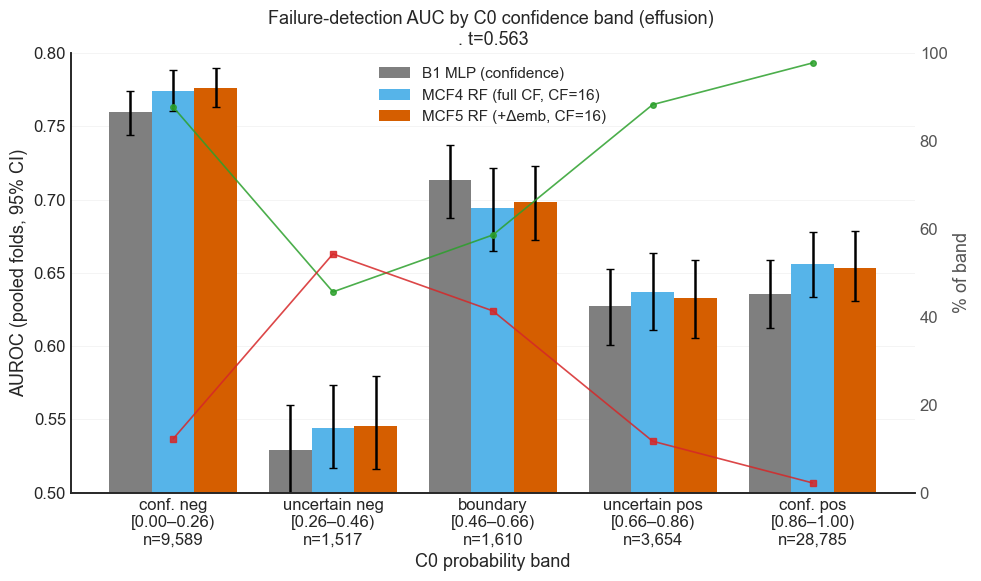

In [87]:


# ── Plot: AUC per C0-confidence band ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

TAGS = ['conf. neg', 'uncertain neg', 'boundary', 'uncertain pos', 'conf. pos']
BAND_LABELS = [f'{tag}\n[{lo:.2f}–{min(hi, 1.0):.2f})'
               for tag, (lo, hi) in zip(TAGS, STRAT_BANDS)]

width = 0.8 / len(strat)
xs = np.arange(len(STRAT_BANDS))
for j, (label, res) in enumerate(strat.items()):
    aucs = [res[b][0] for b in STRAT_BANDS]
    err  = np.array([[res[b][0] - res[b][1] for b in STRAT_BANDS],
                     [res[b][2] - res[b][0] for b in STRAT_BANDS]])
    color = ('#7F7F7F' if label.startswith('B1')
             else list(STRATEGY_COLORS.values())[j])
    ax.bar(xs + j * width, aucs, width, yerr=err, capsize=3,
           color=color, label=label)
    
# ── overlay: % correct / incorrect per band (right axis, 0–100%) ─────────────
pct_corr, pct_err = [], []
for lo, hi in STRAT_BANDS:
    m = (c0d >= lo) & (c0d < hi)
    pct_corr.append(100 * (yc[m] == 1).sum() / m.sum())
    pct_err.append( 100 * (yc[m] == 0).sum() / m.sum())

centers = xs + width * (len(strat) - 1) / 2
ax2 = ax.twinx()
ax2.plot(centers, pct_corr, color='#2ca02c', lw=1.2, marker='o', ms=4, alpha=0.85, label='% C0 correct')
ax2.plot(centers, pct_err,  color='#d62728', lw=1.2, marker='s', ms=4, alpha=0.85, label='% C0 incorrect')
ax2.set_ylabel('% of band', color='#555555')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', colors='#555555')
ax2.grid(False)


ax.axhline(0.5, color='black', ls=':', lw=0.8, alpha=0.6)
ns = [next(iter(strat.values()))[b][3] for b in STRAT_BANDS]
ax.set_xticks(xs + width * (len(strat) - 1) / 2)
ax.set_xticklabels([f'{lab}\nn={n:,}' for lab, n in zip(BAND_LABELS, ns)])
ax.set_xlabel('C0 probability band'); ax.set_ylabel('AUROC (pooled folds, 95% CI)')
ax.set_ylim(0.5, 0.8)
ax.set_title(f'Failure-detection AUC by C0 confidence band ({DISEASE}) \n. t={TAU:.3f}')
ax.legend(loc='upper center', framealpha=0.9, edgecolor='#cccccc')
ax.grid(alpha=0.3, linewidth=0.5, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'confidence_stratified_auc_{DISEASE}.png'),
            dpi=300, bbox_inches='tight')
plt.show()


## 10. Dual-CF Isolation — Does Splitting CFs by Correctness Help?

**Idea tested:** at training time, give each sample *two* counterfactuals — one from the
correct-neighbour pool (TN for a TP query, TP for a TN query) and one from the
incorrect-neighbour pool (FN / FP). At **test time** routing uses predicted label only
(no true-label leakage).

Configs: `B4_single` / `B4_dual` (prob + attrs + CF-attrs) and
`M3_single` / `M3_dual` (prob + attrs + ΔA). Results live in a separate tree:
`results/dual_cf_isolation/{disease}`.

In [5]:
DUAL_CF_BASE = f'{BASE_DIR}/results/dual_cf_isolation/{DISEASE}'
df_k1  = pd.read_csv(f'{DUAL_CF_BASE}/summary_densenet_cf1.csv')
df_k16 = pd.read_csv(f'{DUAL_CF_BASE}/summary_densenet_cf16.csv')

DUAL_CONFIGS  = ['B4_single', 'B4_dual', 'M3_single', 'M3_dual']
config_labels = ['B4 Single', 'B4 Dual', 'M3 Single', 'M3 Dual']
MODEL_COLORS  = {'LR': '#4477AA', 'RF': '#117777', 'MLP': '#BE324A'}
bar_width, x  = 0.22, np.arange(len(DUAL_CONFIGS))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, k_label in [(axes[0], df_k1, 'k = 1 CF'), (axes[1], df_k16, 'k = 16 CFs')]:
    for mi, model in enumerate(MODELS):
        mdf  = df[df['model'] == model].set_index('config')
        aucs = [mdf.loc[c, 'mean_auc'] for c in DUAL_CONFIGS]
        stds = [mdf.loc[c, 'std_auc'] for c in DUAL_CONFIGS]
        ax.bar(x + (mi - 1) * bar_width, aucs, bar_width, yerr=stds, capsize=4,
               color=MODEL_COLORS[model], alpha=0.82, label=MODEL_NAMES[model],
               linewidth=0.8, error_kw=dict(lw=1.2, capthick=1.2))

    # Shade dual-config columns, divide B4 / M3 groups
    for xi in [1, 3]:
        ax.axvspan(xi - 0.4, xi + 0.4, color='#eeeeee', zorder=0, alpha=0.9)
    ax.axvline(1.5, color='#bbbbbb', lw=1.5, ls='--')

    # B1 reference (mean across the three models)
    b1_mean = df[df['config'] == 'B1']['mean_auc'].mean()
    add_b1_line(ax, b1_mean, label='B1 (Prob only, model mean)')
    ax.set_ylim(min(0.70, b1_mean - 0.02), 0.885)

    ax.set_xticks(x); ax.set_xticklabels(config_labels)
    ax.set_xlabel('Config'); ax.set_title(k_label, fontsize=13)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

axes[0].set_ylabel('Mean AUC (5-fold CV)')
axes[1].legend(loc='lower right', framealpha=0.95, edgecolor='#cccccc')
fig.suptitle(f'Dual-CF Isolation: Single vs Dual Correctness Split ({DISEASE})\n'
             'Shaded = dual configs (correct + incorrect CF neighbours). '
             'Error bars = 1 std (5 folds).', fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'dual_cf_isolation_{DISEASE}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'BASE_DIR' is not defined

In [6]:
# ── Paired comparison: dual − single ──────────────────────────────────────────
rows = []
for df_cmp, k in [(df_k1, 1), (df_k16, 16)]:
    for dual_cfg, single_cfg in [('B4_dual', 'B4_single'), ('M3_dual', 'M3_single')]:
        for model in MODELS:
            mdf = df_cmp[df_cmp['model'] == model].set_index('config')
            d_m, s_m = mdf.loc[dual_cfg, 'mean_auc'], mdf.loc[single_cfg, 'mean_auc']
            delta = d_m - s_m
            verdict = ('NO DIFF' if abs(delta) <= mdf.loc[dual_cfg, 'std_auc']
                       else 'DUAL WINS' if delta > 0 else 'DUAL WORSE')
            rows.append({'k': k, 'pair': f'{dual_cfg} vs {single_cfg}', 'model': model,
                         'dual_auc': round(d_m, 4), 'single_auc': round(s_m, 4),
                         'delta': round(delta, 4), 'verdict': verdict})
display(pd.DataFrame(rows))

NameError: name 'df_k1' is not defined

## 11. Appendix — Other Result Trees

These experiments live outside `C2_custom_corrected`:
**11a** C2 across backbone architectures and diseases (`C2_custom` / `C2_resnet50` / `C2_vit`);
**11b** dataset-size ablation (`C2_custom`, effusion-only sub-sampled runs).

*Note: 10a fixes a bug in the previous notebook version, which plotted the effusion
results for all three diseases.*

In [7]:
# ── 11a. C2 AUC across architectures × diseases ───────────────────────────────
ARCH_TREES = {
    'DenseNet-121': f'{BASE_DIR}/results/C2_custom',
    'ResNet-50':    f'{BASE_DIR}/results/C2_resnet50',
    'ViT-B/16':     f'{BASE_DIR}/results/C2_vit',
}
ARCH_COLORS  = {'DenseNet-121': '#4477AA', 'ResNet-50': '#88AACC', 'ViT-B/16': '#117777'}
GEN_DISEASES = ['effusion', 'cardiomegaly', 'pneumothorax']
GEN_MODEL, GEN_CONFIG, GEN_CF = 'LR', 'M6', 16

# C0 validation accuracy (%) per disease (Eff / Card / Pneu), from the C0 runs
C0_ACC = {
    'DenseNet-121': [91.1, 85.2, 75.9],
    'ResNet-50':    [90.5, 85.9, 75.3],
    'ViT-B/16':     [88.8, 82.7, 56.3],
}

gen_auc = np.full((len(ARCH_TREES), len(GEN_DISEASES)), np.nan)
gen_std = np.full_like(gen_auc, np.nan)
for i, tree in enumerate(ARCH_TREES.values()):
    for j, dis in enumerate(GEN_DISEASES):
        path = f'{tree}/{dis}/cv_results/cf_{GEN_CF}/cv_summary.csv'
        if not os.path.exists(path):
            print(f'⚠ missing: {path}')
            continue
        s = pd.read_csv(path)
        row = s[(s['model'] == GEN_MODEL) & (s['config'] == GEN_CONFIG)]
        if row.empty:
            print(f'⚠ {GEN_MODEL}/{GEN_CONFIG} not in {path}')
            continue
        gen_auc[i, j] = row['mean_auc'].iloc[0]
        gen_std[i, j] = row['std_auc'].iloc[0]

x, width = np.arange(len(GEN_DISEASES)), 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, (arch, color) in enumerate(ARCH_COLORS.items()):
    c0_str = ' / '.join(f'{v:.0f}' for v in C0_ACC[arch])
    ax.bar(x + (i - 1) * width, gen_auc[i], width, yerr=gen_std[i], capsize=4,
           color=color, linewidth=1.2, label=f'{arch}  (C0: {c0_str}%)')
ax.set_xticks(x); ax.set_xticklabels([d.capitalize() for d in GEN_DISEASES])
ax.set_ylabel(f'C2 AUC ({GEN_MODEL}, {GEN_CONFIG}, CF={GEN_CF})')
ax.set_xlabel('Disease')
ax.set_ylim(max(0.0, np.nanmin(gen_auc) - 0.05), 1.0)
ax.set_title('C2 Generalizability\n(Across Diseases and Architectures)')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Architecture  (C0 val acc: Eff / Card / Pneu)',
          bbox_to_anchor=(1.02, 1), fontsize=11, title_fontsize=11)

_out = f'{BASE_DIR}/results/C2_generalizability'
os.makedirs(_out, exist_ok=True)
plt.savefig(os.path.join(_out, 'c2_generalizability_across_diseases.png'),
            dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

display(pd.DataFrame(gen_auc, index=list(ARCH_TREES),
                     columns=[d.capitalize() for d in GEN_DISEASES]).round(4))

NameError: name 'BASE_DIR' is not defined

In [8]:
# ── 11b. Dataset-size ablation (C2_custom, effusion, CF=16) ───────────────────
SIZE_TREE = f'{BASE_DIR}/results/C2_custom/effusion/cv_results'
SIZE_RUNS = [('45k (Full)', f'{SIZE_TREE}/cf_16'),
             ('30k',        f'{SIZE_TREE}/cf_16_sub30000'),
             ('20k',        f'{SIZE_TREE}/cf_16_sub20000'),
             ('10k',        f'{SIZE_TREE}/cf_16_sub10000'),
             ('5k',         f'{SIZE_TREE}/cf_16_sub5000')]

size_summ = {}
for lbl, d in SIZE_RUNS:
    p = f'{d}/cv_summary.csv'
    if os.path.exists(p):
        size_summ[lbl] = pd.read_csv(p)
    else:
        print(f'⚠ missing: {p}')

def size_series(config, model='LR'):
    labels, aucs, stds = [], [], []
    for lbl, _ in SIZE_RUNS:
        if lbl not in size_summ:
            continue
        s = size_summ[lbl]
        row = s[(s['model'] == model) & (s['config'] == config)]
        if row.empty:
            print(f'{config}: not in {lbl} run — omitted.')
            continue
        labels.append(lbl)
        aucs.append(row['mean_auc'].iloc[0])
        stds.append(row['std_auc'].iloc[0])
    return labels, aucs, stds

def plot_size_effect(config, highlight, rest, ylim, model='LR'):
    labels, aucs, stds = size_series(config, model)
    plt.figure(figsize=(6, 6))
    plt.bar(labels, aucs, yerr=stds, capsize=10,
            color=[highlight] + [rest] * (len(labels) - 1), linewidth=1.2)
    plt.ylabel('AUC (5-fold CV)'); plt.xlabel('Dataset Size')
    plt.title(f'C2 ({config} | CF=16, {model}) — Effect of Dataset Size (effusion)',
              fontsize=13)
    plt.ylim(*ylim)
    plt.grid(axis='y', alpha=0.3, linewidth=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'dataset_size_{config}_{model}_effusion.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    return pd.DataFrame({'Dataset Size': labels, 'AUC': aucs, 'AUC Std': stds})

df_m3 = plot_size_effect('M3', '#117777', '#88AACC', ylim=(0.95, 1))
df_m6 = plot_size_effect('M6', '#D04B4B', '#839BB3', ylim=(0.98, 1))
display(df_m3.round(4)); display(df_m6.round(4))
print(df_m6.to_latex(index=False, float_format='%.4f'))

NameError: name 'BASE_DIR' is not defined